In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.utils as vutils
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torch.utils.data import DataLoader, random_split, Subset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
import copy
from tqdm.auto import tqdm
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

paths = [
    "artifacts/figures",
]

for path in paths:
    os.makedirs(path, exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)
csv_path = "artifacts/runs.csv"
if not os.path.exists(csv_path):
    with open(csv_path, 'w') as f:
        f.write("experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes\n")

Using device: cpu


c:\Users\koshk\aiecity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Классификация изображений

Batch size: 64, X.shape: torch.Size([64, 3, 96, 96]), Y.shape: torch.Size([64])


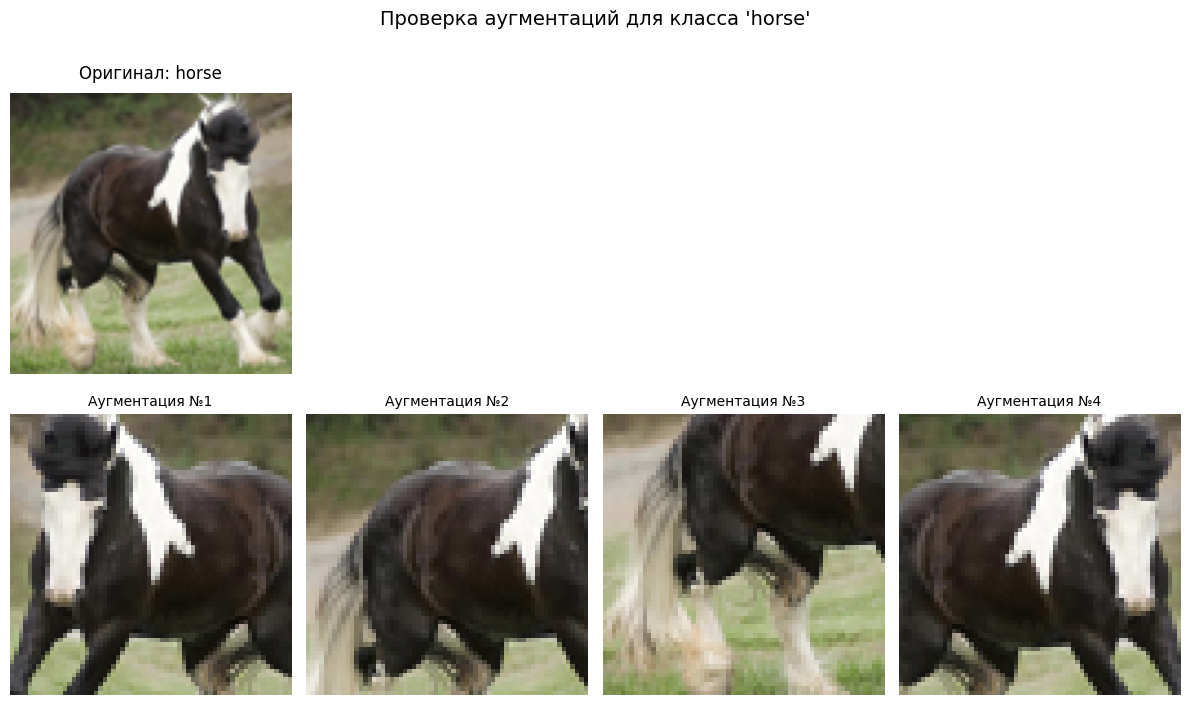

In [2]:
base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

aug_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(64, padding=4),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка STL10
train_full = torchvision.datasets.STL10(root='./data', split='train', download=True)
test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=base_transform)

# Валидация 80/20
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_indices, val_indices = random_split(range(len(train_full)), [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

# Обертка для применения разных трансформаций к одному датасету
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return self.transform(img), label
    def __len__(self):
        return len(self.indices)

train_loader_base = DataLoader(TransformDataset(train_full, train_indices, base_transform), batch_size=64, shuffle=True)
train_loader_aug = DataLoader(TransformDataset(train_full, train_indices, aug_transform), batch_size=64, shuffle=True)
val_loader = DataLoader(TransformDataset(train_full, val_indices, base_transform), batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Sanity check
images, labels = next(iter(train_loader_base))
print(f"Batch size: {images.shape[0]}, X.shape: {images.shape}, Y.shape: {labels.shape}")

stl10_classes = [
    'airplane', 'bird', 'car', 'cat', 'deer',
    'dog', 'horse', 'monkey', 'ship', 'truck'
]

def show_augmentations_preview(dataset_raw, aug_transform, classes, n_cols=4, out_path=None):
    idx = np.random.randint(len(dataset_raw))
    img_pil, label = dataset_raw[idx]
    class_name = classes[label]


    fig, axs = plt.subplots(2, n_cols, figsize=(3 * n_cols, 7))

    axs[0, 0].imshow(img_pil)
    axs[0, 0].set_title(f"Оригинал: {class_name}", fontsize=12, pad=10)
    axs[0, 0].axis("off")

    for j in range(1, n_cols):
        axs[0, j].axis("off")

    for j in range(n_cols):
        aug_tensor = aug_transform(img_pil)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        aug_vis = torch.clamp(aug_tensor * std + mean, 0, 1)

        aug_vis = aug_vis.permute(1, 2, 0).numpy()

        axs[1, j].imshow(aug_vis)
        axs[1, j].set_title(f"Аугментация №{j+1}", fontsize=10)
        axs[1, j].axis("off")

    plt.suptitle(f"Проверка аугментаций для класса '{class_name}'", fontsize=14, y=1.02)
    plt.tight_layout()

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)


show_augmentations_preview(
    dataset_raw=train_full,
    aug_transform=aug_transform,
    classes=stl10_classes,
    n_cols=4,
    out_path="artifacts/figures/augmentations_preview.png"
)

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    start_time = time.time()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan"), 0.0

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    duration = time.time() - start_time
    return total_loss / total_seen, total_correct / total_seen, duration

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

In [4]:
EPOCHS = 10
experiments_A = [
    ("C1", "simple-cnn-base", train_loader_base),
    ("C2", "simple-cnn-aug", train_loader_aug),
    ("C3", "resnet18-head-only", train_loader_base),
    ("C4", "resnet18-finetune", train_loader_base)
]

results = []
best_val_acc_overall = 0.0
best_model_state = None
best_history = None

for exp_id, name, t_loader in experiments_A:
    print(f"\nЗапуск {exp_id}: {name}")

    if "simple-cnn" in name:
        model = SimpleCNN().to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    else:
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 10)
        model = model.to(device)
        if "head-only" in name:
            for param in model.parameters(): param.requires_grad = False
            for param in model.fc.parameters(): param.requires_grad = True
            optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
        else: # finetune
            for param in model.parameters(): param.requires_grad = False
            for param in model.layer4.parameters(): param.requires_grad = True
            for param in model.fc.parameters(): param.requires_grad = True
            optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    criterion = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_acc = 0.0
    for epoch in range(EPOCHS):
        t_loss, t_acc, t_time = train_one_epoch(model, t_loader, optimizer, criterion)
        v_loss, v_acc = evaluate(model, val_loader, criterion)

        hist["train_loss"].append(t_loss); hist["val_loss"].append(v_loss)
        hist["train_acc"].append(t_acc); hist["val_acc"].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            if best_val_acc > best_val_acc_overall:
                best_val_acc_overall = best_val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                best_history = hist
                best_cfg = {
            "experiment_id": exp_id,
            "model_name": name,
            "dataset": "STL10",
            "epochs": EPOCHS,
            "seed": SEED,
            "input_size": [3, 96, 96],
            "num_classes": 10,
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
            "augmentation": "aug",
        }
                
        t_time = round(t_time, 2)
        print(f"Epoch {epoch+1}/{EPOCHS} - Val Acc: {v_acc:.4f} - {t_time} s")

    _, test_acc = evaluate(model, test_loader, criterion)
    
    results.append({
        "experiment_id": exp_id, "task": "classification", "dataset": "STL10",
        "seed": 42, "model_summary": "SimpleCNN (3-conv, ~0,62M)" if "simple-cnn" in name else
                         "ResNet18 (ImageNet, head-only)" if "head-only" in name else
                         "ResNet18 (ImageNet, layer4+fc)", "optimizer": "Adam", "lr": optimizer.param_groups[0]['lr'],
        "epochs_trained": EPOCHS, "best_val_accuracy": best_val_acc, "test_accuracy": test_acc
    })


Запуск C1: simple-cnn-base
Epoch 1/10 - Val Acc: 0.3740 - 37.62 s
Epoch 2/10 - Val Acc: 0.4310 - 39.0 s
Epoch 3/10 - Val Acc: 0.4910 - 40.29 s
Epoch 4/10 - Val Acc: 0.5160 - 40.28 s
Epoch 5/10 - Val Acc: 0.5560 - 39.97 s
Epoch 6/10 - Val Acc: 0.5360 - 38.06 s
Epoch 7/10 - Val Acc: 0.5700 - 27.23 s
Epoch 8/10 - Val Acc: 0.5410 - 25.34 s
Epoch 9/10 - Val Acc: 0.5720 - 25.02 s
Epoch 10/10 - Val Acc: 0.5880 - 25.74 s

Запуск C2: simple-cnn-aug
Epoch 1/10 - Val Acc: 0.2730 - 13.25 s
Epoch 2/10 - Val Acc: 0.3850 - 13.25 s
Epoch 3/10 - Val Acc: 0.3770 - 13.81 s
Epoch 4/10 - Val Acc: 0.4130 - 14.42 s
Epoch 5/10 - Val Acc: 0.4070 - 13.71 s
Epoch 6/10 - Val Acc: 0.4890 - 13.36 s
Epoch 7/10 - Val Acc: 0.5140 - 13.38 s
Epoch 8/10 - Val Acc: 0.5160 - 13.72 s
Epoch 9/10 - Val Acc: 0.5240 - 13.5 s
Epoch 10/10 - Val Acc: 0.5710 - 13.49 s

Запуск C3: resnet18-head-only
Epoch 1/10 - Val Acc: 0.7410 - 22.42 s
Epoch 2/10 - Val Acc: 0.7700 - 22.67 s
Epoch 3/10 - Val Acc: 0.8000 - 22.35 s
Epoch 4/10 - Val 

In [5]:
torch.save(best_model_state, "artifacts/best_classifier.pt")
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_cfg, f)

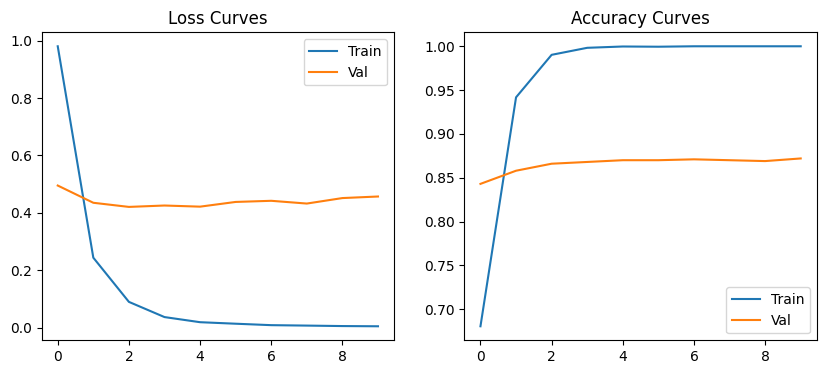

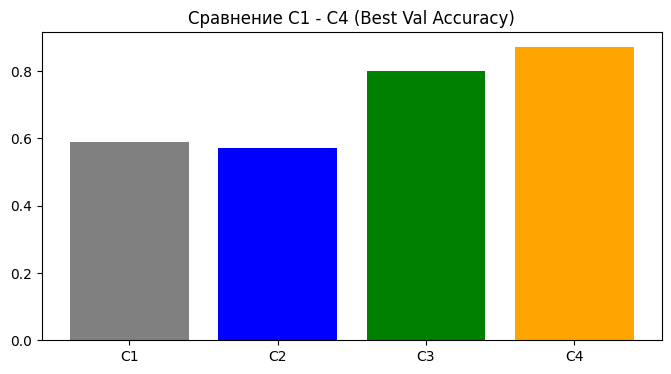

In [6]:
# Графики: Кривые обучения лучшей модели
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history["train_loss"], label="Train")
plt.plot(best_history["val_loss"], label="Val")
plt.title("Loss Curves")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(best_history["train_acc"], label="Train")
plt.plot(best_history["val_acc"], label="Val")
plt.title("Accuracy Curves")
plt.legend()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

# Графики: Сравнение C1-C4
c_res = pd.DataFrame(results)
plt.figure(figsize=(8, 4))
plt.bar(c_res['experiment_id'], c_res['best_val_accuracy'], color=['gray', 'blue', 'green', 'orange'])
plt.title("Сравнение C1 - C4 (Best Val Accuracy)")
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

Сегментация изображений

In [ ]:
seg_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# В датасете: 1 - foreground (животное), 2 - background, 3 - border
target_transform = T.Compose([
    T.Resize((256, 256), interpolation=T.InterpolationMode.NEAREST),
    T.PILToTensor(),
    T.Lambda(lambda x: (x.squeeze() == 1).to(torch.uint8)) # Делаем бинарную маску (1 = foreground, 0 = background)
])

seg_ds = torchvision.datasets.OxfordIIITPet(root='./data', target_types='segmentation', download=True,
                                            transform=seg_transform, target_transform=target_transform)
seg_loader = DataLoader(Subset(seg_ds, range(20)), batch_size=1) # Инференс на 20 картинках

# Загрузка готовой модели DeepLabV3
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT).to(device).eval()

def compute_metrics(pred, target):
    intersection = (pred & target).sum().float()
    union = (pred | target).sum().float()
    iou = (intersection + 1e-6) / (union + 1e-6)

    tp = intersection
    fp = (pred & ~target).sum().float()
    fn = (~pred & target).sum().float()

    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    return iou.item(), precision.item(), recall.item()

import scipy.ndimage as nd

examples_to_plot = []

for mode in ["V1", "V2"]:
    print(f"\nЗапуск {mode} (Сегментация)")
    metrics = {"iou": [], "prec": [], "rec": []}

    with torch.no_grad():
        for i, (img, gt_mask) in enumerate(seg_loader):
            img = img.to(device)
            out = seg_model(img)['out'][0]
            pred_mask = (out.argmax(0).cpu() > 0).to(torch.uint8)

            if mode == "V2":
                pred_mask = torch.tensor(nd.binary_closing(pred_mask.numpy(), iterations=3)).to(torch.uint8)

            iou, prec, rec = compute_metrics(pred_mask, gt_mask[0])
            metrics["iou"].append(iou); metrics["prec"].append(prec); metrics["rec"].append(rec)

            if i < 3: # Сохраняем примеры
                examples_to_plot.append({'img': img[0].cpu(), 'gt': gt_mask[0], 'pred': pred_mask, 'mode': mode, 'iou': iou})

    results.append({
        "experiment_id": mode, "seed": 42, "model_summary": "DeepLabV3_ResNet50 pretrained, pet foreground with probs", "task": "segmentation", "dataset": "OxfordIIITPet",
        "mean_iou": np.mean(metrics["iou"]), "precision": np.mean(metrics["prec"]), "recall": np.mean(metrics["rec"]),
        "notes": "Base mask" if mode == "V1" else "Morphological closing"
    })


Запуск V1 (Сегментация)

Запуск V2 (Сегментация)


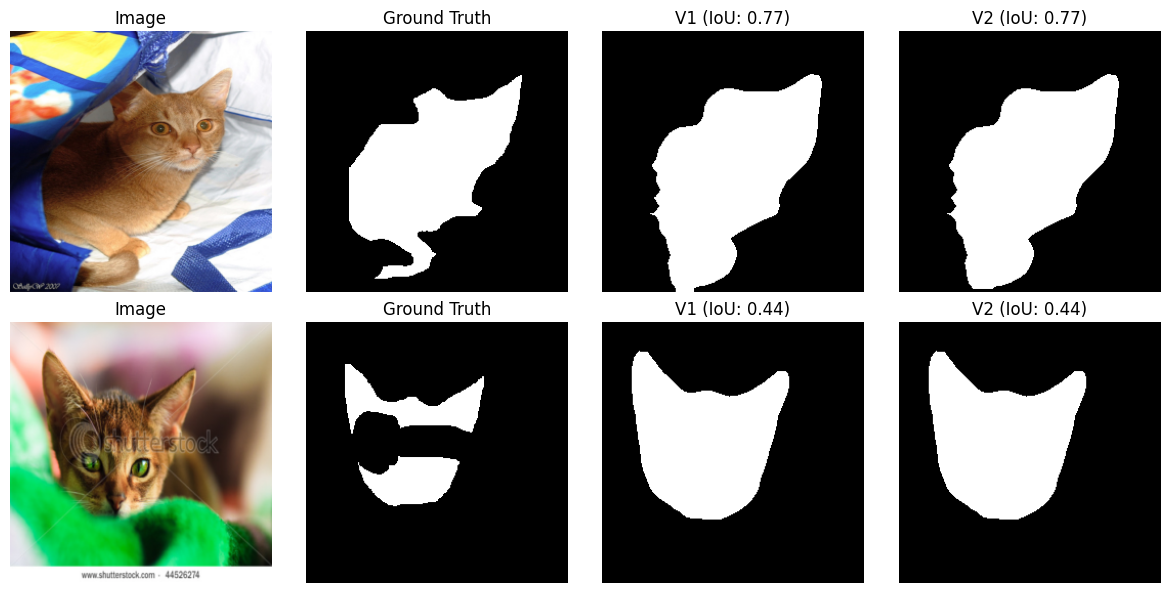

In [8]:
# Визуализация примеров сегментации
plt.figure(figsize=(12, 6))
for i in range(2):
    v1_ex = [ex for ex in examples_to_plot if ex['mode'] == 'V1'][i]
    v2_ex = [ex for ex in examples_to_plot if ex['mode'] == 'V2'][i]

    # Денормализация для показа
    mean, std = torch.tensor([0.485, 0.456, 0.406]), torch.tensor([0.229, 0.224, 0.225])
    img_show = torch.clamp(v1_ex['img'].permute(1,2,0) * std + mean, 0, 1)

    plt.subplot(2, 4, i*4 + 1); plt.imshow(img_show); plt.title("Image"); plt.axis('off')
    plt.subplot(2, 4, i*4 + 2); plt.imshow(v1_ex['gt'], cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(2, 4, i*4 + 3); plt.imshow(v1_ex['pred'], cmap='gray'); plt.title(f"V1 (IoU: {v1_ex['iou']:.2f})"); plt.axis('off')
    plt.subplot(2, 4, i*4 + 4); plt.imshow(v2_ex['pred'], cmap='gray'); plt.title(f"V2 (IoU: {v2_ex['iou']:.2f})"); plt.axis('off')

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.show()

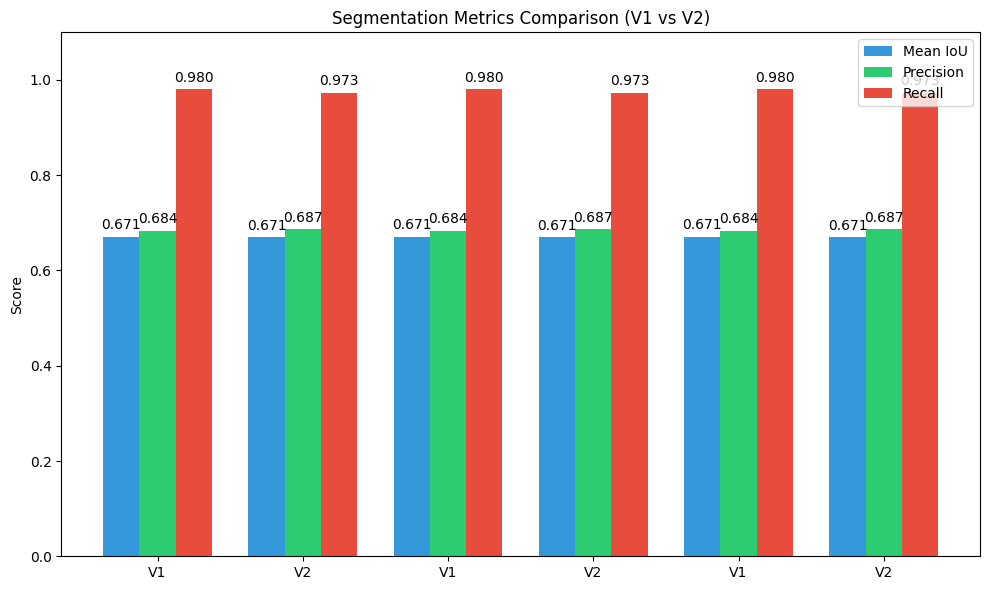

In [9]:
df_runs = pd.read_csv("artifacts/runs.csv")
# Фильтруем только данные по сегментации (V1 и V2)
seg_data = df_runs[df_runs['task'] == 'segmentation'].copy()

# Превращаем метрики в числа (на случай, если они записаны как строки)
for col in ['mean_iou', 'precision', 'recall']:
    seg_data[col] = pd.to_numeric(seg_data[col])

labels = seg_data['experiment_id'].values # ['V1', 'V2']
iou = seg_data['mean_iou'].values
prec = seg_data['precision'].values
rec = seg_data['recall'].values

x = np.arange(len(labels))  # Позиции групп столбцов
width = 0.25  # Ширина столбца

fig, ax = plt.subplots(figsize=(10, 6))

# Рисуем три группы столбцов
rects1 = ax.bar(x - width, iou, width, label='Mean IoU', color='#3498db')
rects2 = ax.bar(x, prec, width, label='Precision', color='#2ecc71')
rects3 = ax.bar(x + width, rec, width, label='Recall', color='#e74c3c')

# Добавляем текст, заголовки и метки
ax.set_ylabel('Score')
ax.set_title('Segmentation Metrics Comparison (V1 vs V2)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1) # Метрики от 0 до 1
ax.legend()

# Функция для подписи значений над столбцами
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

save_path = "artifacts/figures/segmentation_metrics.png"
plt.savefig(save_path)
plt.show()

In [13]:
reader = pd.DataFrame(results)
reader = pd.read_csv('artifacts/runs.csv')
for i in range(4):
    if reader.loc[i]["experiment_id"] != best_cfg["experiment_id"]:
        reader.loc[i, "test_accuracy"] = np.nan

reader.to_csv("artifacts/runs.csv", index=False)
print(reader[["experiment_id", "task", "best_val_accuracy", "mean_iou", "test_accuracy"]])

  experiment_id            task  best_val_accuracy  mean_iou  test_accuracy
0            C1  classification              0.575       NaN            NaN
1            C2  classification              0.549       NaN            NaN
2            C3  classification              0.800       NaN            NaN
3            C4  classification              0.873       NaN       0.867875
4            V1    segmentation                NaN  0.671317            NaN
5            V2    segmentation                NaN  0.670529            NaN
